In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import joblib

In [ ]:
# Load data
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'
df = pd.read_csv(url)

In [ ]:
# Tampilkan 5 baris pertama dengan function head.
df.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


In [ ]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [ ]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


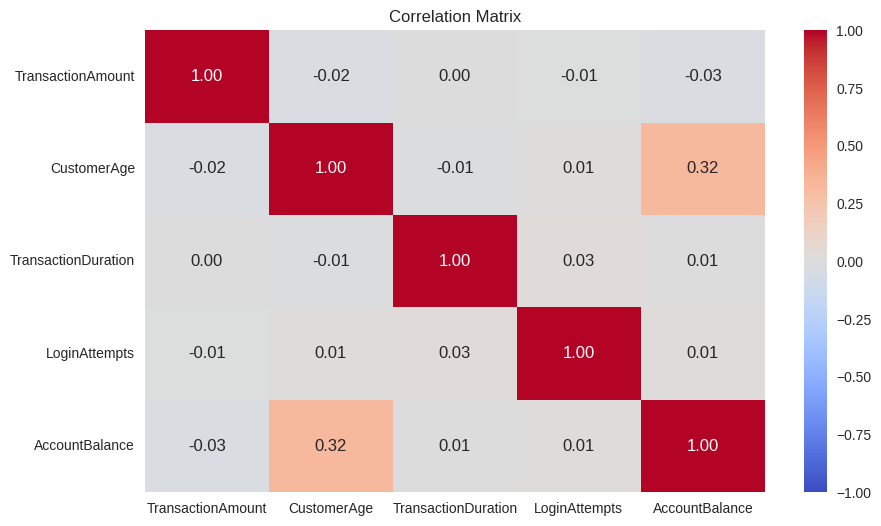

In [ ]:
# Menampilkan korelasi antar fitur

# Memilih kolom numerik
numerical_cols = df.select_dtypes(include = ['number']).columns

# Hitung matriks correlation
correlation = df[numerical_cols].corr()

# Buat visualisasi heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation,
               annot=True,
               cmap='coolwarm',
               fmt=".2f",
               vmin=-1,
               vmax=1)
plt.title('Correlation Matrix')
plt.show()

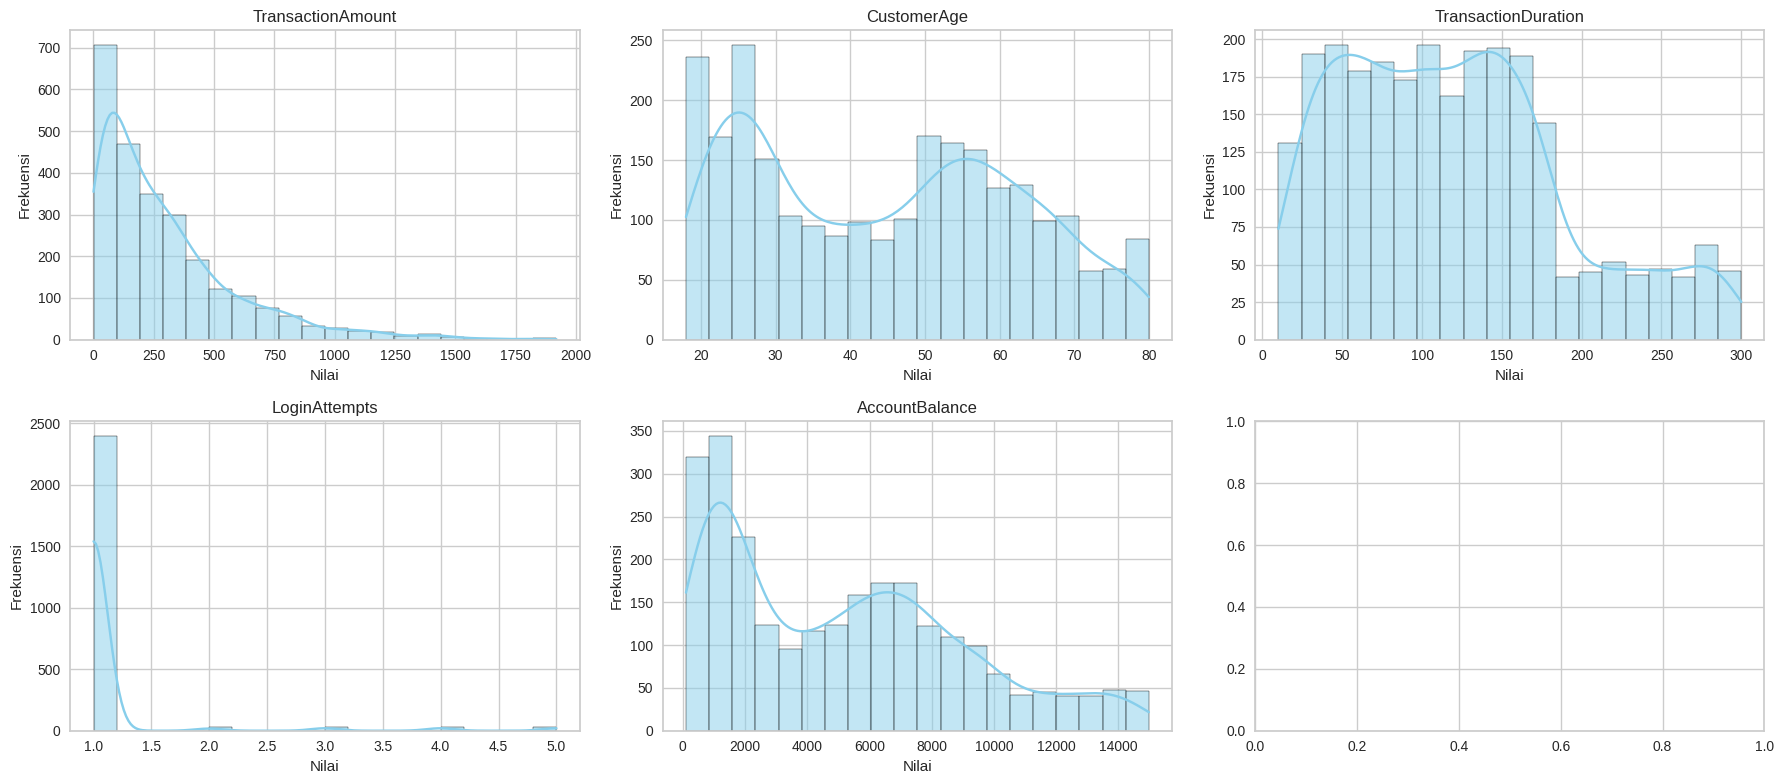

In [ ]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(numerical_cols):
    sns.histplot(df[column], bins=20, kde=True, color='skyblue', ax = axes[i])
    axes[i].set_title(column)
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

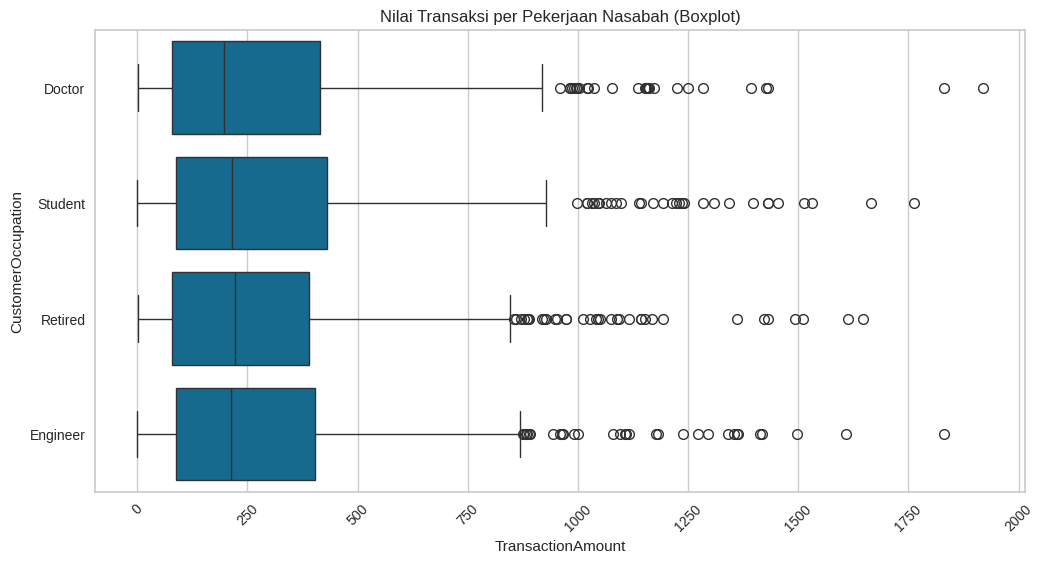

In [ ]:
# Visualisasi yang lebih informatif
plt.figure(figsize=(12, 6))
sns.boxplot(x='TransactionAmount', y='CustomerOccupation', data=df)
plt.title("Nilai Transaksi per Pekerjaan Nasabah (Boxplot)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Mengecek dataset menggunakan isnull().sum(). Cek apakah ada missing value
df.isnull().sum()

,0
TransactionID,29
AccountID,21
TransactionAmount,26
PreviousTransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [ ]:
# Mengecek dataset menggunakan duplicated().sum(). Cek apakah ada duplikasi data
df.duplicated().sum()

np.int64(21)

In [ ]:
# Menangani data yang hilang.
df.dropna(inplace=True)
df.isnull().sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
PreviousTransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


In [ ]:
# Menghapus data duplikat.
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [ ]:
# Melakukan drop pada kolom yang memiliki keterangan Date, id, dan IP Address

cols_to_drop = [col for col in df.columns if
                'id' in col.lower() or
                'ip' in col.lower() or
                'date' in col.lower()]

df = df.drop(columns=cols_to_drop)
df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68


In [ ]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.

categorical_cols = list(df.select_dtypes(include=['object']).columns)
encoders = {}

for column in categorical_cols:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column] = label_encoder

df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06
5,92.15,1,28,0,18.0,3,172.0,1.0,781.68


In [ ]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
df.columns.tolist()

['TransactionAmount',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance']

In [ ]:
# Melakukan Handling Outlier Data menggunakan metode drop.
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

df.describe()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
count,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.0,1945.000000
mean,256.838278,0.771722,21.299743,0.977378,44.693059,1.503342,119.225193,1.0,5100.811913
std,218.370197,0.419830,12.329250,0.804119,17.743453,1.135888,70.600647,0.0,3907.153333
min,0.260000,0.000000,0.000000,0.000000,18.000000,0.000000,10.000000,1.0,102.200000
25%,78.920000,1.000000,11.000000,0.000000,27.000000,0.000000,63.000000,1.0,1488.650000
50%,199.700000,1.000000,21.000000,1.000000,45.000000,1.000000,111.000000,1.0,4693.600000
75%,374.500000,1.000000,32.000000,2.000000,59.000000,3.000000,162.000000,1.0,7659.990000
max,903.190000,1.000000,42.000000,2.000000,80.000000,3.000000,300.000000,1.0,14977.990000


In [ ]:
# Melakukan feature scaling menggunakan StandardScaler() untuk fitur numerik.
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726


In [ ]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik
col_to_bin = 'CustomerAge' 
new_col_name = 'New_Column'
bin_labels = ['Low', 'Mid', 'High']

df[new_col_name] = pd.qcut(df[col_to_bin], q=3, labels=bin_labels, duplicates='drop')

label_encoder = LabelEncoder()
df[new_col_name] = label_encoder.fit_transform(df[new_col_name])

encoders[new_col_name] = label_encoder
categorical_cols.extend([new_col_name])

df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,New_Column
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918,0
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531,0
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513,1
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895,1
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726,1


In [ ]:
# Describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
df_used = df.copy()
df_used.describe()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,New_Column
count,1.945000e+03,1945.000000,1945.000000,1945.000000,1.945000e+03,1945.000000,1.945000e+03,1945.0,1.945000e+03,1945.000000
mean,-8.402305e-17,0.771722,21.299743,0.977378,-1.269479e-16,1.503342,2.557223e-17,0.0,-6.027740e-17,1.001028
std,1.000257e+00,0.419830,12.329250,0.804119,1.000257e+00,1.135888,1.000257e+00,0.0,1.000257e+00,0.810171
min,-1.175271e+00,0.000000,0.000000,0.000000,-1.504776e+00,0.000000,-1.547483e+00,0.0,-1.279678e+00,0.000000
25%,-8.149648e-01,1.000000,11.000000,0.000000,-9.974163e-01,0.000000,-7.965883e-01,0.0,-9.247374e-01,0.000000
50%,-2.617251e-01,1.000000,21.000000,1.000000,1.730327e-02,1.000000,-1.165330e-01,0.0,-1.042490e-01,1.000000
75%,5.389562e-01,1.000000,32.000000,2.000000,8.065296e-01,3.000000,6.060257e-01,0.0,6.551666e-01,2.000000
max,2.960651e+00,1.000000,42.000000,2.000000,1.990369e+00,3.000000,2.561185e+00,0.0,2.528623e+00,2.000000


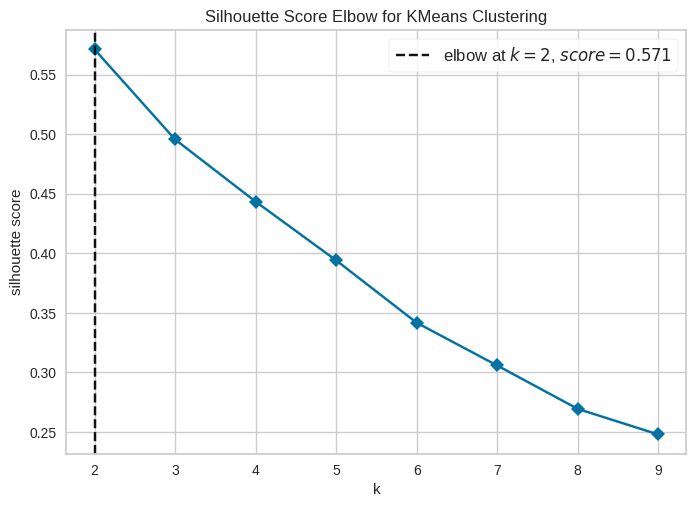

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()
model = KMeans()

visualizer = KElbowVisualizer(model,
                       k=(2,10),
                       metric='silhouette',
                       timings=False)

visualizer.fit(df)
visualizer.show()

In [ ]:
# Menyimpan model menggunakan joblib
joblib.dump(model, "model_clustering.h5")

['model_clustering.h5']

In [ ]:
# Menghitung dan menampilkan nilai Silhouette Score.
labels = model.labels_
score = silhouette_score(df, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.4959763687323938


/tmp/ipython-input-2309177638.py:19: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


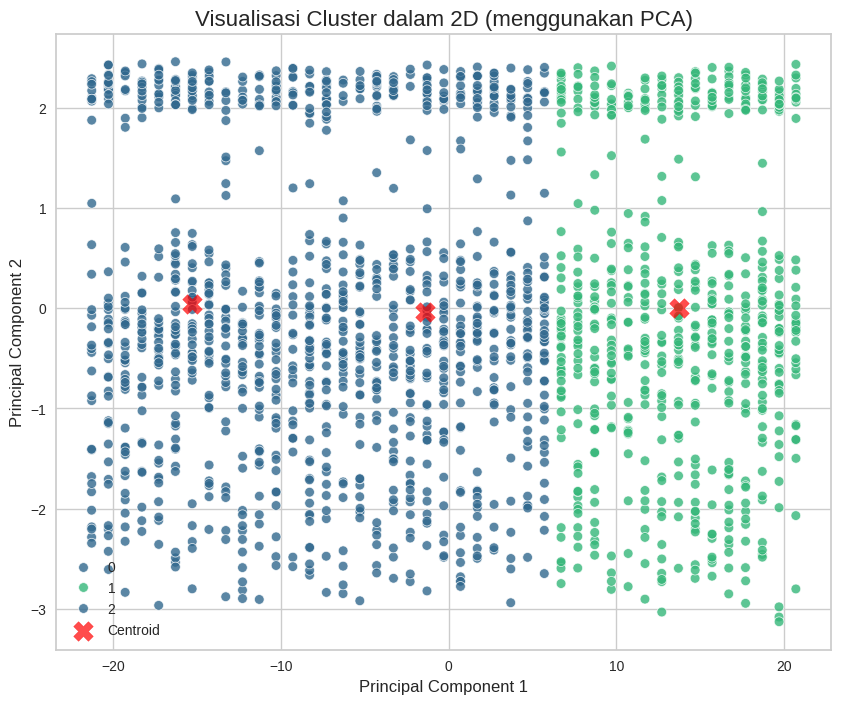

In [ ]:
# Membuat visualisasi hasil clustering
pca = PCA(n_components = 2)

df_pca = pca.fit_transform(df)
df_pca = pd.DataFrame(data=df_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['Cluster'] = labels

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster', 
    palette=sns.color_palette("viridis", n_colors=2),
    data=df_pca,
    legend="full",
    alpha=0.8
)

plt.title('Visualisasi Cluster dalam 2D (menggunakan PCA)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
centers = pca.transform(model.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.7, marker='X', label='Centroid')
plt.legend()
plt.show()

In [ ]:
# Membangun model menggunakan PCA.
pca = PCA(n_components=2)

df_pca_array = pca.fit_transform(df_used)
data_final = pd.DataFrame(data=df_pca_array, columns=['PCA1', 'PCA2'])

kmeans_pca = KMeans(n_clusters=2, random_state=42)
kmeans_pca.fit(data_final)

KMeans(n_clusters=2, random_state=42)

In [ ]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")
joblib.dump(kmeans_pca, "PCA_model_clustering.h5")

['PCA_model_clustering.h5']

In [ ]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
df_used['Cluster'] = labels

agg_summary = df_used.groupby('Cluster')[numerical_cols].agg(['mean', 'min', 'max']).round(2).T
display(agg_summary)

Cluster                      0     1     2
TransactionAmount   mean -0.01  0.01  0.00
                    min  -1.17 -1.18 -1.17
                    max   2.96  2.90  2.90
CustomerAge         mean  0.01 -0.05  0.04
                    min  -1.50 -1.50 -1.50
                    max   1.99  1.99  1.99
TransactionDuration mean  0.01 -0.03  0.02
                    min  -1.55 -1.55 -1.55
                    max   2.56  2.55  2.55
LoginAttempts       mean  0.00  0.00  0.00
                    min   0.00  0.00  0.00
                    max   0.00  0.00  0.00
AccountBalance      mean -0.03  0.00  0.02
                    min  -1.28 -1.28 -1.28
                    max   2.52  2.53  2.52

In [ ]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
df_used.rename(columns={"Cluster": "Target"}, inplace=True)
df_used.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,New_Column,Target
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918,0,1
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531,0,2
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513,1,2
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895,1,1
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726,1,1


In [ ]:
# Simpan Data
df_used.to_csv('data_clustering.csv', index=False)

In [ ]:
# inverse dataset ke rentang normal untuk numerikal
df_inverse = df_used.copy()
df_inverse[numerical_cols] = scaler.inverse_transform(df_inverse[numerical_cols])
df_inverse.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,New_Column,Target
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21,0,1
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91,0,2
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35,1,2
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06,1,1
5,92.15,1,28,0,18.0,3,172.0,1.0,781.68,1,1


In [ ]:
# inverse dataset yang sudah diencode ke kategori aslinya.
for column in categorical_cols:
    encoder = encoders[column]
    df_inverse[column] = encoder.inverse_transform(df_inverse[column].astype(int))

df_inverse.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,New_Column,Target
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,High,1
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,High,2
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,Low,2
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,Low,1
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,Low,1


In [ ]:
agg_summary_num = df_inverse.groupby('Target')[numerical_cols].agg(['mean', 'min', 'max']).round(2).T
agg_summary_cat = df_inverse.groupby('Target')[categorical_cols].agg(lambda x: x.mode()[0]).round(2).T

display(agg_summary_num)
display(agg_summary_cat)

Target                           0         1         2
TransactionAmount   mean    254.56    258.21    257.29
                    min       0.32      0.26      0.45
                    max     903.19    889.01    890.24
CustomerAge         mean     44.84     43.85     45.41
                    min      18.00     18.00     18.00
                    max      80.00     80.00     80.00
TransactionDuration mean    119.74    117.31    120.70
                    min      10.00     10.00     10.00
                    max     300.00    299.00    299.00
LoginAttempts       mean      1.00      1.00      1.00
                    min       1.00      1.00      1.00
                    max       1.00      1.00      1.00
AccountBalance      mean   5001.21   5109.80   5170.92
                    min     117.98    102.20    112.76
                    max   14935.50  14977.99  14942.78

Target,0,1,2
TransactionType,Debit,Debit,Debit
Location,Charlotte,Tucson,Fort Worth
Channel,Branch,Branch,Branch
CustomerOccupation,Student,Student,Engineer
New_Column,Low,Low,Mid


1. **Cluster 1: Pelanggan Ekonomis dengan Saldo Terbatas**:
  - Rata-rata (mean) : TransactionAmount: Rp 254,56, CustomerAge: 44,84 tahun, TransactionDuration: 119,74 menit, LoginAttempts: 1,00 kali, AccountBalance: Rp 5.001,21
  - Rentang: TransactionAmount: [Rp 0,32 - Rp 903,19], CustomerAge: [18 - 80 tahun], TransactionDuration: [10 - 300 menit], LoginAttempts: [1 - 1 kali], AccountBalance: [Rp 117,98 - Rp 14.935,50]
  - **Analisis:** Cluster ini merepresentasikan pelanggan dengan saldo akun terendah di antara semua cluster (Rp 5.001,21), meskipun nilai transaksi rata-ratanya juga paling rendah (Rp 254,56). Kelompok ini didominasi oleh pelanggan usia menengah (44,84 tahun) dengan durasi transaksi paling lama (119,74 menit), mengindikasikan mereka lebih berhati-hati dan teliti dalam bertransaksi karena keterbatasan finansial. Dengan saldo minimum hanya Rp 117,98, cluster ini menunjukkan profil nasabah entry-level atau mahasiswa/pekerja baru yang masih membangun stabilitas keuangan. Cocok untuk produk simpanan mikro, KTA ringan, atau program literasi keuangan.

2. **Cluster 2: Pelanggan Muda Efisien dengan Nilai Transaksi Tertinggi**:
  - Rata-rata (mean) : TransactionAmount: Rp 258,21, CustomerAge: 43,85 tahun, TransactionDuration: 117,31 menit, LoginAttempts: 1,00 kali, AccountBalance: Rp 5.109,80
  - Rentang: TransactionAmount: [Rp 0,26 - Rp 889,01], CustomerAge: [18 - 80 tahun], TransactionDuration: [10 - 299 menit], LoginAttempts: [1 - 1 kali], AccountBalance: [Rp 102,20 - Rp 14.977,99]
  - **Analisis:** Cluster ini adalah kelompok pelanggan termuda (43,85 tahun) dengan durasi transaksi paling singkat (117,31 menit) dan nilai transaksi tertinggi (Rp 258,21). Kombinasi ini menggambarkan segmen pelanggan produktif dan efisien, seorang Student yang aktif bertransaksi dengan cepat. Meskipun saldo mereka menengah (Rp 5.109,80), nilai transaksi yang lebih besar menunjukkan cash flow yang lebih aktif. Saldo minimum terendah (Rp 102,20) mengindikasikan ada sub-segmen yang agresif dalam menggunakan dana. Cocok untuk produk investasi jangka pendek, credit card, dan layanan digital banking premium.

3. **Cluster 3: Pelanggan Senior Premium dengan Stabilitas Finansial Tinggi"**:
  - Rata-rata (mean) : TransactionAmount: Rp 257,29, ustomerAge: 45,41 tahun, TransactionDuration: 120,70 menit, LoginAttempts: 1,00 kali, AccountBalance: Rp 5.170,92
  - Rentang: TransactionAmount: [Rp 0,45 - Rp 890,24], CustomerAge: [18 - 80 tahun], TransactionDuration: [10 - 299 menit], LoginAttempts: [1 - 1 kali], AccountBalance: [Rp 112,76 - Rp 14.942,78]
  - **Analisis:** Cluster ini adalah kelompok pelanggan termuda (45,51 tahun) dengan durasi transaksi paling singkat (120,70 menit) dan nilai transaksi tertinggi (Rp 257,29). Kombinasi ini menggambarkan segmen pelanggan produktif dan efisien, seorang Engineer yang aktif bertransaksi dengan cepat. Meskipun saldo mereka menengah (Rp 5.170,92), nilai transaksi yang lebih besar menunjukkan cash flow yang lebih aktif. Saldo minimum terendah (Rp 112,76) mengindikasikan ada sub-segmen yang agresif dalam menggunakan dana. Cocok untuk produk investasi jangka pendek, credit card, dan layanan digital banking premium.



In [ ]:
df_inverse.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,New_Column,Target
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,High,1
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,High,2
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,Low,2
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,Low,1
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,Low,1


In [ ]:
# Simpan Data Inverse
df_inverse.to_csv('data_clustering_inverse.csv', index=False)